Importing Dataset and libraries

In [2]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def fetch_housing_data():
    # 1. Create a folder path to save our data
    tarball_path = Path("datasets/housing/housing.tgz")

    # 2. Check if the file already exists
    if not tarball_path.is_file():
        Path("datasets/housing").mkdir(parents=True, exist_ok=True)

        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)

        # 3. Unzip the file.
        # FIX: We now extract to just "datasets" because the zip file already contains a "housing" folder!
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")

    # 4. Read the unzipped text file into our Pandas spreadsheet
    return pd.read_csv(Path("datasets/housing/housing.csv"))

# Run the function
housing = fetch_housing_data()

/tmp/ipykernel_1405/1217949478.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


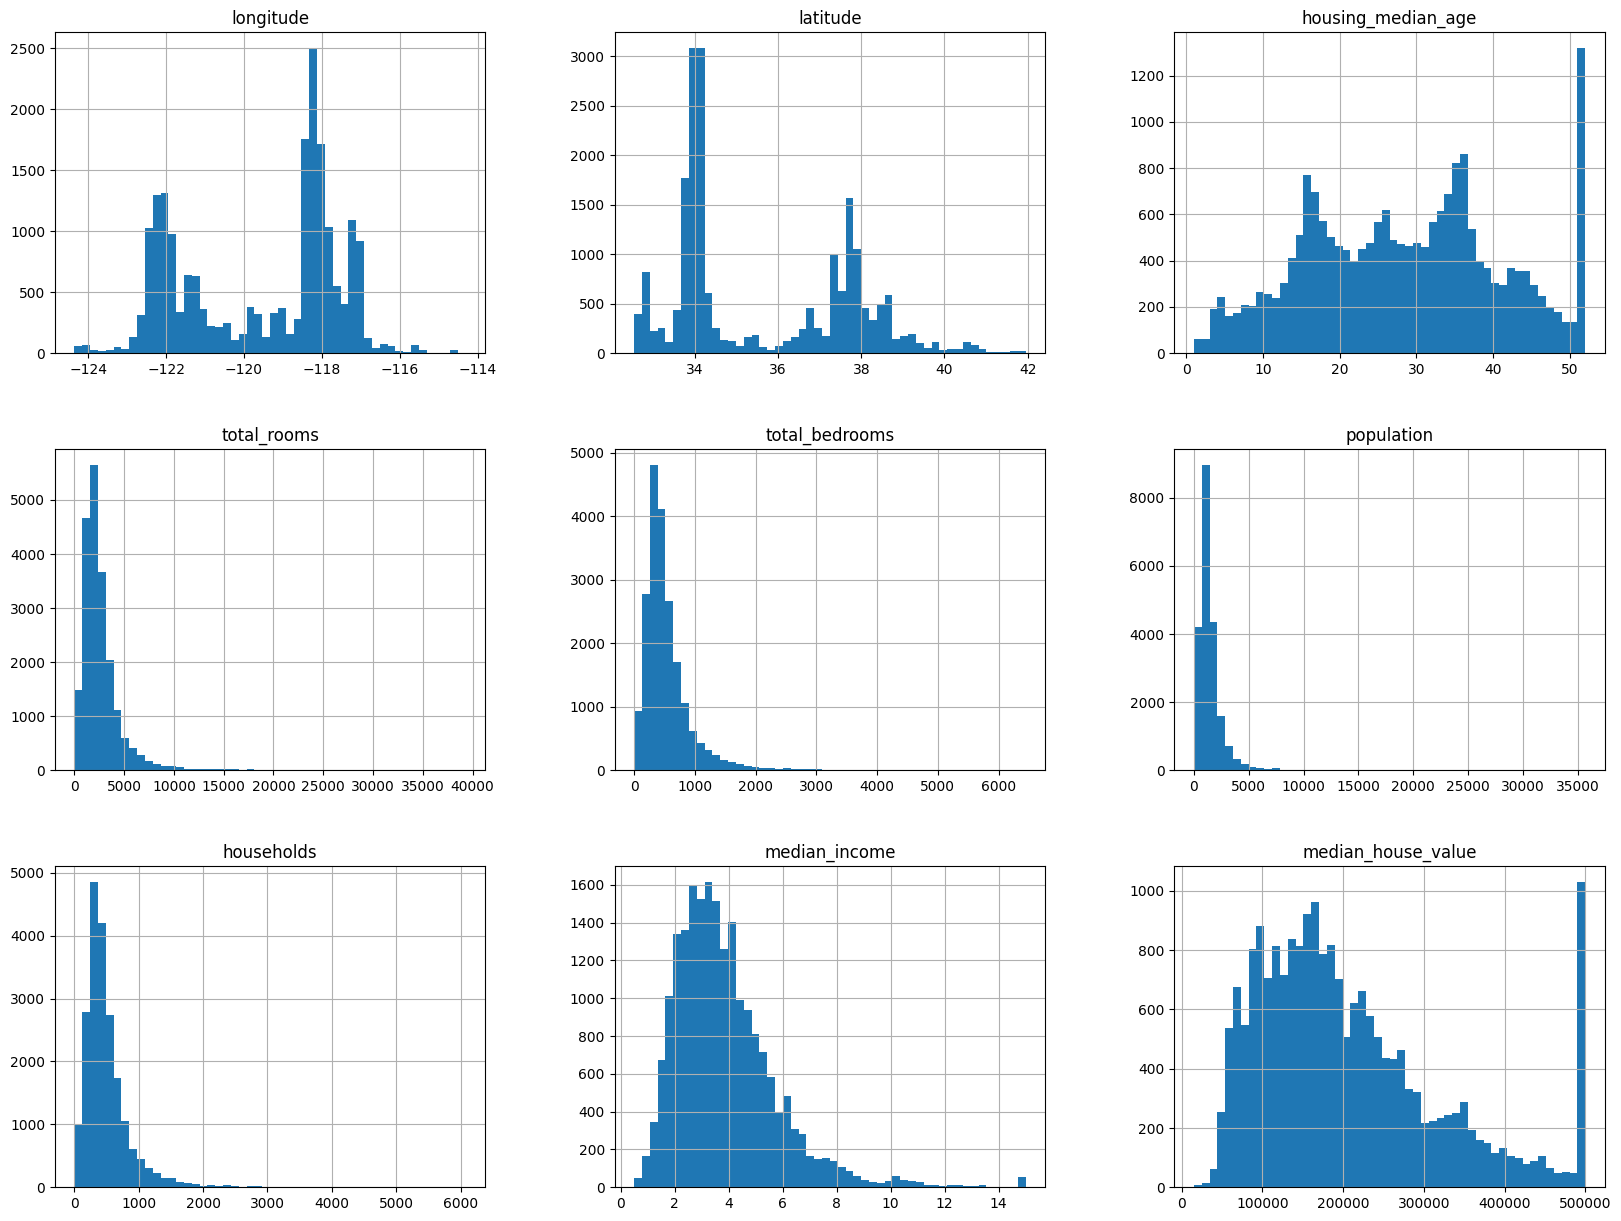

In [7]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20,15))
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

len(train_set), len(test_set)

(16512, 4128)

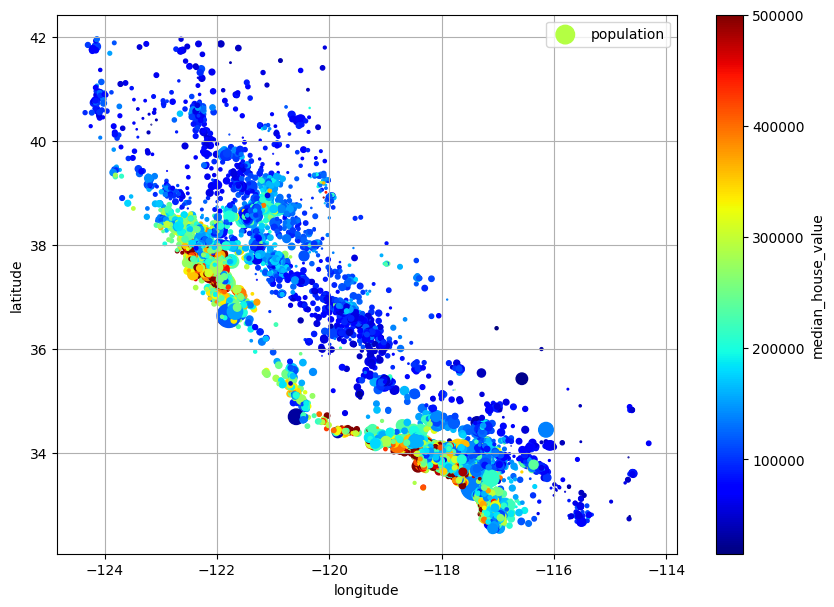

In [9]:
# make a copy of training set

housing_explore = train_set.copy()

# create a plot for analysis
housing_explore.plot(kind="scatter", x = "longitude", y = "latitude", grid=True, s=housing_explore["population"]/100, label="population", figsize=(10,7), c="median_house_value", cmap="jet", colorbar=True, legend=True, sharex=False)
plt.show()

In [10]:
# Corelate every feature with the median price
corr_matrix = housing_explore.corr(numeric_only=True)

print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.687013
total_rooms           0.134060
housing_median_age    0.104714
households            0.065798
total_bedrooms        0.049993
population           -0.025820
longitude            -0.043603
latitude             -0.146324
Name: median_house_value, dtype: float64


<Axes: xlabel='median_income', ylabel='median_house_value'>

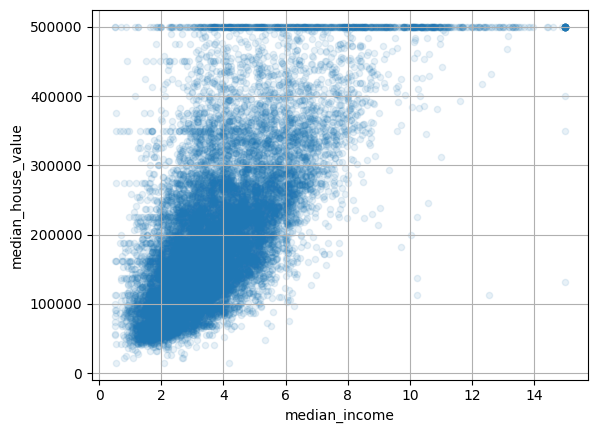

In [11]:
housing_explore.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid="True")

In [12]:
# Feature engineering
housing_explore["rooms_per_household"] = housing_explore["total_rooms"]/housing_explore["households"]
housing_explore["bedrooms_per_room"] = housing_explore["total_bedrooms"]/housing_explore["total_rooms"]
housing_explore["population_per_household"] = housing_explore["population"]/housing_explore["households"]

corr_matrix = housing_explore.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value          1.000000
median_income               0.687013
rooms_per_household         0.146940
total_rooms                 0.134060
housing_median_age          0.104714
households                  0.065798
total_bedrooms              0.049993
population_per_household   -0.021577
population                 -0.025820
longitude                  -0.043603
latitude                   -0.146324
bedrooms_per_room          -0.254817
Name: median_house_value, dtype: float64


In [13]:
housing = train_set.drop("median_house_value", axis=1)
housing_labels = train_set["median_house_value"].copy()

Pipeline

In [14]:
from sklearn.impute import SimpleImputer
import numpy as np

# Create an imputer object using a median strategy
imputer = SimpleImputer(strategy="median")

# Imputer only performs on numerical attributes so create numericaly only dataset
housing_num = housing.select_dtypes(include=[np.number])

imputer.fit(housing_num)

#print calculated medians for each attribute
imputer.statistics_

# transform given median values to fill the missing values in the dataset
X = imputer.transform(housing_num)


In [15]:
housing_trans = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
housing_trans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


In [16]:
from sklearn.preprocessing import OneHotEncoder

# Create an encoder object
ctg_encoder = OneHotEncoder()

# Create an object to store categorical attribute
housing_ctg = housing[["ocean_proximity"]]

# Apply encoder object to categorial data and transform it
housing_ctg_1hot = ctg_encoder.fit_transform(housing_ctg)

print(housing_ctg_1hot.toarray()[:5])


[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]


Direct Data Pipeline

In [17]:
# Making a Data pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder
import numpy as np

preprocessor = make_column_transformer(
    # pipeline for numerical attributes
    (make_pipeline(IterativeImputer(random_state=42), StandardScaler()), make_column_selector(dtype_include=np.number)),
    # pipeline for categorical attributes
    (OneHotEncoder(handle_unknown="ignore"), make_column_selector(dtype_include=object))
)

# Put data through this pipeline
housing_prepared = preprocessor.fit_transform(housing)
housing_prepared[:5]

array([[ 1.17299302, -1.35041487,  0.42853749,  1.57055658,  1.37095619,
         1.0810111 ,  1.50750741,  0.37969797,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ],
       [ 1.26802809, -1.37853628, -1.47350948, -0.8094394 , -0.89996034,
        -0.64384214, -0.87870693,  0.42006824,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ],
       [-1.3529389 ,  0.98834939, -0.04697426,  1.9942892 ,  2.43215452,
         1.36319568,  2.5938282 , -0.09231969,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ],
       [-1.12785585,  0.75869118, -0.28473013,  0.64655814,  0.22831148,
         0.66126154,  0.39481962,  0.68299933,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 1.79322185, -1.08326143, -1.63201339, -1.11790554, -1.18023169,
        -1.20380217, -1.25575517, -1.25556038,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ]])

Linear Regression

In [18]:
# Training Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Fit the model to the training data
model.fit(housing_prepared, housing_labels)


LinearRegression()

In [19]:
# 1. Grab 5 raw districts from our original dataset
some_data = housing.iloc[5:10]
some_labels = housing_labels.iloc[5:10]

# 2. Pass those 5 districts through our cleaning pipeline
some_data_prepared = preprocessor.transform(some_data)

# 3. Ask the AI to predict the prices
print("Your Model Predictions:", model.predict(some_data_prepared).round(0))
print("Actual Prices: ", list(some_labels))

Your Model Predictions: [516755.  69517. 203743.  64494. 219998.]
Actual Prices:  [500001.0, 54400.0, 145800.0, 173400.0, 172600.0]


In [20]:
# Evaluating error

from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Ask the AI to predict the price for ALL 16,512 districts in the training set
housing_predictions = model.predict(housing_prepared)

# 2. Calculate the Mean Squared Error (MSE) by comparing predictions to the actual labels
lin_mse = mean_squared_error(housing_labels, housing_predictions)

# 3. Take the square root to turn the error back into normal dollars (RMSE)
lin_rmse = np.sqrt(lin_mse)

print("Average Model Error (RMSE): $", lin_rmse.round(2))

Average Model Error (RMSE): $ 68381.45


Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Create the new, self-correcting model
gb_reg = HistGradientBoostingRegressor(random_state=42)

# 2. Train it on your fully prepared pipeline data
gb_reg.fit(housing_prepared, housing_labels)

HistGradientBoostingRegressor(random_state=42)

Cross Validation

In [22]:
# Cross validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(gb_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
#RMSE score of descision tree
gb_rmse_scores = np.sqrt(-scores)

def display_scores(scores):
    print("Scores:", scores.round(0))
    print("Mean:", scores.mean().round(0))
    print("Standard Deviation:", scores.std().round(0))

display_scores(gb_rmse_scores)

Scores: [46592. 48459. 49027. 44973. 48669. 45967. 48650. 46984. 47913. 48461.]
Mean: 47569.0
Standard Deviation: 1297.0


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Create the base model
gb_reg = HistGradientBoostingRegressor(random_state=42)

# 2. Define the new grid of dials specific to Gradient Boosting
param_grid = [
    {
        'learning_rate': [0.05, 0.1, 0.2], # How fast it corrects mistakes
        'max_iter': [100, 200, 300],       # The maximum number of trees to build
        'max_depth': [3, 5, None],         # How deep/complex each individual tree can get
        'l2_regularization': [0.0, 0.1]    # A math trick to prevent overfitting
    }
]

# 3. Create the Search Robot (cv=5 means 5 practice quizzes per combination)
# This grid has 54 combinations * 5 quizzes = 270 models to train!
gb_grid_search = GridSearchCV(gb_reg, param_grid, cv=5,
                              scoring='neg_mean_squared_error',
                              return_train_score=True)

print("Starting the ultimate Grid Search... 🚀")

# 4. Unleash the robot on the prepared data!
gb_grid_search.fit(housing_prepared, housing_labels)

print("Search Complete! 🎉")
print("Best Hyperparameters:", gb_grid_search.best_params_)

# 5. Get the final, ultimate error score!
final_gb_model = gb_grid_search.best_estimator_
gb_predictions = final_gb_model.predict(housing_prepared)
from sklearn.metrics import mean_squared_error
import numpy as np
print("Ultimate Tuned RMSE: $", np.sqrt(mean_squared_error(housing_labels, gb_predictions)).round(2))

Starting the ultimate Grid Search... 🚀
Search Complete! 🎉
Best Hyperparameters: {'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_depth': None, 'max_iter': 300}
Ultimate Tuned RMSE: $ 33447.11


In [ ]:
from sklearn.inspection import permutation_importance

# 1. Ask the Grid Search for the absolute best model it built
final_gb_model = gb_grid_search.best_estimator_

print("Shuffling columns to test importance... 🕵️‍♂️")

# 2. Run the Permutation Importance test (n_repeats=10 means it shuffles each column 10 times to be sure)
result = permutation_importance(final_gb_model, housing_prepared, housing_labels, n_repeats=10, random_state=42)

# 3. Rebuild your attribute names list
extra_attribs = ["rooms_per_household", "population_per_household", "bedrooms_per_room"]
cat_encoder = preprocessor.named_transformers_["onehotencoder"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = list(housing_num.columns) + extra_attribs + cat_one_hot_attribs

# 4. Print them out side-by-side!
print("\nFeature Importances (How much the error increased when shuffled):")
for importance, name in sorted(zip(result.importances_mean, attributes), reverse=True):
    print(f"{name:<25}: {importance:.2f}")

Shuffling columns to test importance... 🕵️‍♂️

Feature Importances (How much the error increased when shuffled):
longitude                : 0.79
latitude                 : 0.69
median_income            : 0.50
population               : 0.15
total_rooms              : 0.15
population_per_household : 0.11
total_bedrooms           : 0.05
housing_median_age       : 0.05
households               : 0.03
INLAND                   : 0.01
rooms_per_household      : 0.01
<1H OCEAN                : 0.01
bedrooms_per_room        : 0.00


Testing DataSet

In [26]:
# Evaluate on the test set
X_test = test_set.drop("median_house_value", axis=1)
y_test = test_set["median_house_value"].copy()

# clean the test set
X_test_prepared = preprocessor.transform(X_test)

final_predictions = final_gb_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print("Final Model Test RMSE: $", final_rmse.round(2))

Final Model Test RMSE: $ 46713.52
